<a href="https://colab.research.google.com/github/George1902/bienestar_equino/blob/main/Analisis_Bienestar_Equino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bienestar y Supervivencia Equina
## ¿Qué nos dicen los datos sobre el estado emocional y físico de los caballos?

**Autor:** Jorge Ojeda  
**Fecha:** Marzo 2026  
**Fuente de datos:** Horse Survival Dataset — Kaggle

## Objetivo
Analizar indicadores clínicos y de comportamiento de caballos
para identificar patrones de estrés, dolor y bienestar,
y clasificar qué caballos tienen mayor riesgo de no sobrevivir.

## Preguntas que responde este análisis
- ¿Qué indicadores físicos se asocian más con el sufrimiento?
- ¿Existen perfiles de bienestar diferenciados?
- ¿Puede un modelo predecir la supervivencia de un caballo?
- ¿Qué variables son más determinantes para su bienestar?

# Fase 1 — Exploración Inicial

##  Montar Drive e importar librerías

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerias cargadas correctamente")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Librerias cargadas correctamente


## Cargar dataset

In [37]:
ruta = '/content/drive/MyDrive/Colab Notebooks/horse.csv'
df = pd.read_csv(ruta)

print(f"✅ Dataset cargado: {df.shape[0]} caballos, {df.shape[1]} variables")
print("\n=== PRIMERAS FILAS ===")
display(df.head(10))

✅ Dataset cargado: 299 caballos, 28 variables

=== PRIMERAS FILAS ===


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no
5,no,adult,528355,NaN,NaN,NaN,warm,normal,pale_pink,less_3_sec,...,NaN,NaN,NaN,NaN,lived,no,0,0,0,no
6,yes,adult,526802,37.9,48.0,16.0,normal,normal,normal_pink,less_3_sec,...,37.0,7.0,NaN,NaN,lived,yes,3124,0,0,no
7,yes,adult,529607,NaN,60.0,NaN,cool,NaN,NaN,less_3_sec,...,44.0,8.3,NaN,NaN,died,yes,2208,0,0,no
8,no,adult,530051,NaN,80.0,36.0,cool,absent,pale_pink,less_3_sec,...,38.0,6.2,NaN,NaN,euthanized,yes,3205,0,0,no
9,no,young,5299629,38.3,90.0,NaN,normal,NaN,normal_pink,less_3_sec,...,40.0,6.2,clear,2.2,lived,no,0,0,0,yes


## Explorar columnas

In [3]:
print("=== COLUMNAS DISPONIBLES ===")
for col in df.columns:
    print(f"  {col}: {df[col].dtype} — ejemplo: {df[col].iloc[0]}")

=== COLUMNAS DISPONIBLES ===
  surgery: object — ejemplo: no
  age: object — ejemplo: adult
  hospital_number: int64 — ejemplo: 530101
  rectal_temp: float64 — ejemplo: 38.5
  pulse: float64 — ejemplo: 66.0
  respiratory_rate: float64 — ejemplo: 28.0
  temp_of_extremities: object — ejemplo: cool
  peripheral_pulse: object — ejemplo: reduced
  mucous_membrane: object — ejemplo: nan
  capillary_refill_time: object — ejemplo: more_3_sec
  pain: object — ejemplo: extreme_pain
  peristalsis: object — ejemplo: absent
  abdominal_distention: object — ejemplo: severe
  nasogastric_tube: object — ejemplo: nan
  nasogastric_reflux: object — ejemplo: nan
  nasogastric_reflux_ph: float64 — ejemplo: nan
  rectal_exam_feces: object — ejemplo: decreased
  abdomen: object — ejemplo: distend_large
  packed_cell_volume: float64 — ejemplo: 45.0
  total_protein: float64 — ejemplo: 8.4
  abdomo_appearance: object — ejemplo: nan
  abdomo_protein: float64 — ejemplo: nan
  outcome: object — ejemplo: died
  su

##  Estadísticas básicas y nulos

In [4]:
print("=== ESTADISTICAS GENERALES ===")
display(df.describe())

print("\n=== VALORES NULOS ===")
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))

=== ESTADISTICAS GENERALES ===


,hospital_number,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
count,2.990000e+02,239.000000,275.000000,241.000000,53.000000,270.000000,266.000000,101.000000,299.000000,299.000000,299.000000
mean,1.087733e+06,38.168619,72.000000,30.460581,4.707547,46.307407,24.274436,3.039604,3659.709030,90.528428,7.387960
std,1.532032e+06,0.733744,28.646219,17.666102,1.982311,10.436743,27.364194,1.967947,5408.472421,650.637139,127.749768
min,5.184760e+05,35.400000,30.000000,8.000000,1.000000,23.000000,3.300000,0.100000,0.000000,0.000000,0.000000
25%,5.289040e+05,37.800000,48.000000,18.000000,3.000000,38.000000,6.500000,2.000000,2111.500000,0.000000,0.000000
50%,5.303010e+05,38.200000,64.000000,25.000000,5.000000,45.000000,7.500000,2.300000,2322.000000,0.000000,0.000000
75%,5.347360e+05,38.500000,88.000000,36.000000,6.500000,52.000000,56.750000,3.900000,3209.000000,0.000000,0.000000
max,5.305629e+06,40.800000,184.000000,96.000000,7.500000,75.000000,89.000000,10.100000,41110.000000,7111.000000,2209.000000



=== VALORES NULOS ===


,Nulos,Porcentaje (%)
nasogastric_reflux_ph,246,82.27
abdomo_protein,198,66.22
abdomo_appearance,165,55.18
abdomen,118,39.46
nasogastric_reflux,106,35.45
nasogastric_tube,104,34.78
rectal_exam_feces,102,34.11
peripheral_pulse,69,23.08
rectal_temp,60,20.07
respiratory_rate,58,19.40


## Distribución de la variable objetivo

In [5]:
print("=== DISTRIBUCIÓN DE SUPERVIVENCIA ===")
print(df['outcome'].value_counts())
print()
print(df['outcome'].value_counts(normalize=True).mul(100).round(2))

=== DISTRIBUCIÓN DE SUPERVIVENCIA ===
outcome
lived         178
died           77
euthanized     44
Name: count, dtype: int64

outcome
lived         59.53
died          25.75
euthanized    14.72
Name: proportion, dtype: float64


## ✅ Conclusiones de la Fase 1 — Exploración Inicial

- El dataset contiene **299 caballos** con **28 variables clínicas**
- La variable objetivo `outcome` tiene 3 categorías:
  - **Lived (59.53%)** — 178 caballos sobrevivieron
  - **Died (25.75%)** — 77 caballos murieron
  - **Euthanized (14.72%)** — 44 fueron sacrificados
- Variables con más nulos: `nasogastric_reflux_ph` (82%),
  `abdomo_protein` (66%), `abdomo_appearance` (55%)
- El pulso promedio es de **72 ppm** — muy por encima del
  rango normal (28-44 ppm), indicando estrés severo

**Siguiente fase:** Limpieza y preparación de datos

# Fase 2 — Limpieza y Preparación de Datos

En esta fase vamos a:
- Eliminar columnas con más del 50% de nulos
- Imputar valores nulos en columnas clave
- Codificar variables categóricas
- Crear variable de nivel de bienestar
- Guardar dataset limpio

## Eliminar columnas con muchos nulos

In [6]:
# Eliminar columnas con más del 50% de nulos
umbral = 50
nulos_pct = (df.isnull().sum() / len(df) * 100)
columnas_eliminar = nulos_pct[nulos_pct > umbral].index.tolist()

df_limpio = df.drop(columns=columnas_eliminar).copy()

print(f"✅ Columnas eliminadas ({len(columnas_eliminar)}): {columnas_eliminar}")
print(f"📊 Columnas restantes: {df_limpio.shape[1]}")

✅ Columnas eliminadas (3): ['nasogastric_reflux_ph', 'abdomo_appearance', 'abdomo_protein']
📊 Columnas restantes: 25


## Eliminar columnas irrelevantes

In [7]:
# Eliminar columnas que no aportan al análisis
columnas_irrelevantes = ['hospital_number', 'lesion_1',
                          'lesion_2', 'lesion_3']

df_limpio = df_limpio.drop(
    columns=[c for c in columnas_irrelevantes
             if c in df_limpio.columns]
)

print(f"✅ Columnas irrelevantes eliminadas")
print(f"📊 Columnas finales: {df_limpio.shape[1]}")
print(list(df_limpio.columns))

✅ Columnas irrelevantes eliminadas
📊 Columnas finales: 21
['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'outcome', 'surgical_lesion', 'cp_data']


## Imputar valores nulos

In [8]:
# Columnas numéricas: imputar con mediana
columnas_num = df_limpio.select_dtypes(include='number').columns
for col in columnas_num:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

# Columnas categóricas: imputar con moda
columnas_cat = df_limpio.select_dtypes(include='object').columns
for col in columnas_cat:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mode()[0])

print(f"✅ Valores nulos imputados")
print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

✅ Valores nulos imputados
Nulos restantes: 0


##  Crear índice de bienestar

In [9]:
# Crear índice de bienestar basado en indicadores clínicos
# Pulso normal en caballos: 28-44 ppm
# Temperatura normal: 37.5-38.5°C

def calcular_bienestar(row):
    score = 0

    # Pulso (menor es mejor)
    if row['pulse'] <= 44:
        score += 3
    elif row['pulse'] <= 60:
        score += 2
    elif row['pulse'] <= 80:
        score += 1

    # Temperatura
    if 37.5 <= row['rectal_temp'] <= 38.5:
        score += 2
    elif 37.0 <= row['rectal_temp'] <= 39.0:
        score += 1

    # Dolor
    if row['pain'] == 'none':
        score += 3
    elif row['pain'] == 'depressed':
        score += 2
    elif row['pain'] == 'mild_pain':
        score += 1

    # Peristalsis
    if row['peristalsis'] == 'normal':
        score += 2
    elif row['peristalsis'] == 'hypomotile':
        score += 1

    return score

df_limpio['indice_bienestar'] = df_limpio.apply(
    calcular_bienestar, axis=1)

print("✅ Indice de bienestar creado")
print(f"Rango: {df_limpio['indice_bienestar'].min()} — "
      f"{df_limpio['indice_bienestar'].max()}")
print(f"Promedio: {df_limpio['indice_bienestar'].mean():.2f}")

✅ Indice de bienestar creado
Rango: 0 — 9
Promedio: 4.36


## Clasificar nivel de bienestar

In [10]:
def clasificar_bienestar(score):
    if score >= 8:
        return 'Alto'
    elif score >= 5:
        return 'Moderado'
    elif score >= 2:
        return 'Bajo'
    else:
        return 'Critico'

df_limpio['nivel_bienestar'] = df_limpio['indice_bienestar'].apply(
    clasificar_bienestar)

print("✅ Niveles de bienestar:")
print(df_limpio['nivel_bienestar'].value_counts())
print()
print("Bienestar vs Outcome:")
print(pd.crosstab(df_limpio['nivel_bienestar'],
                  df_limpio['outcome']))

✅ Niveles de bienestar:
nivel_bienestar
Bajo        146
Moderado    137
Critico      11
Alto          5
Name: count, dtype: int64

Bienestar vs Outcome:
outcome          died  euthanized  lived
nivel_bienestar                         
Alto                0           2      3
Bajo               53          28     65
Critico             5           4      2
Moderado           19          10    108


##  Codificar variables categóricas para ML

In [11]:
from sklearn.preprocessing import LabelEncoder

df_ml = df_limpio.copy()
le = LabelEncoder()

columnas_cat_ml = df_ml.select_dtypes(include='object').columns.tolist()
columnas_cat_ml = [c for c in columnas_cat_ml
                   if c != 'outcome' and c != 'nivel_bienestar']

for col in columnas_cat_ml:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print("✅ Variables codificadas para ML")
print(f"Columnas procesadas: {columnas_cat_ml}")

✅ Variables codificadas para ML
Columnas procesadas: ['surgery', 'age', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen', 'surgical_lesion', 'cp_data']


##  Guardar dataset limpio

In [12]:
ruta_limpio = '/content/drive/MyDrive/horse_limpio.csv'
df_limpio.to_csv(ruta_limpio, index=False)

print(f"✅ Dataset limpio guardado")
print(f"📊 {len(df_limpio)} caballos, {df_limpio.shape[1]} variables")
display(df_limpio[['pain', 'pulse', 'rectal_temp',
                    'outcome', 'indice_bienestar',
                    'nivel_bienestar']].head(10))

✅ Dataset limpio guardado
📊 299 caballos, 23 variables


,pain,pulse,rectal_temp,outcome,indice_bienestar,nivel_bienestar
0,extreme_pain,66.0,38.5,died,3,Bajo
1,mild_pain,88.0,39.2,euthanized,1,Critico
2,mild_pain,40.0,38.3,lived,7,Moderado
3,depressed,164.0,39.1,died,2,Bajo
4,mild_pain,104.0,37.3,died,3,Bajo
5,depressed,64.0,38.2,lived,6,Moderado
6,mild_pain,48.0,37.9,lived,6,Moderado
7,mild_pain,60.0,38.2,died,5,Moderado
8,severe_pain,80.0,38.2,euthanized,3,Bajo
9,extreme_pain,90.0,38.3,lived,3,Bajo


## ✅ Conclusiones de la Fase 2 — Limpieza y Preparación

- Se eliminaron **3 columnas** con más del 50% de nulos
- Dataset final con **21 variables** limpias
- Valores nulos imputados correctamente — **0 nulos restantes**
- Índice de bienestar creado con rango 0-9, promedio **4.36**
- Distribución de niveles:
  - Bajo: 146 caballos (mayoría del plantel)
  - Moderado: 137 caballos
  - Crítico: 11 caballos
  - Alto: solo 5 caballos
- Hallazgo clave: caballos en nivel **Crítico** sobreviven
  apenas en el 18% de los casos

**Siguiente fase:** Visualizaciones avanzadas

# Fase 3 — Visualizaciones Avanzadas

En esta fase exploraremos visualmente:
- Distribución de supervivencia
- Niveles de bienestar vs outcome
- Indicadores clínicos por resultado
- Mapa de calor de correlaciones
- Distribución de dolor y estrés

##  Gráfico 1: Distribución de supervivencia

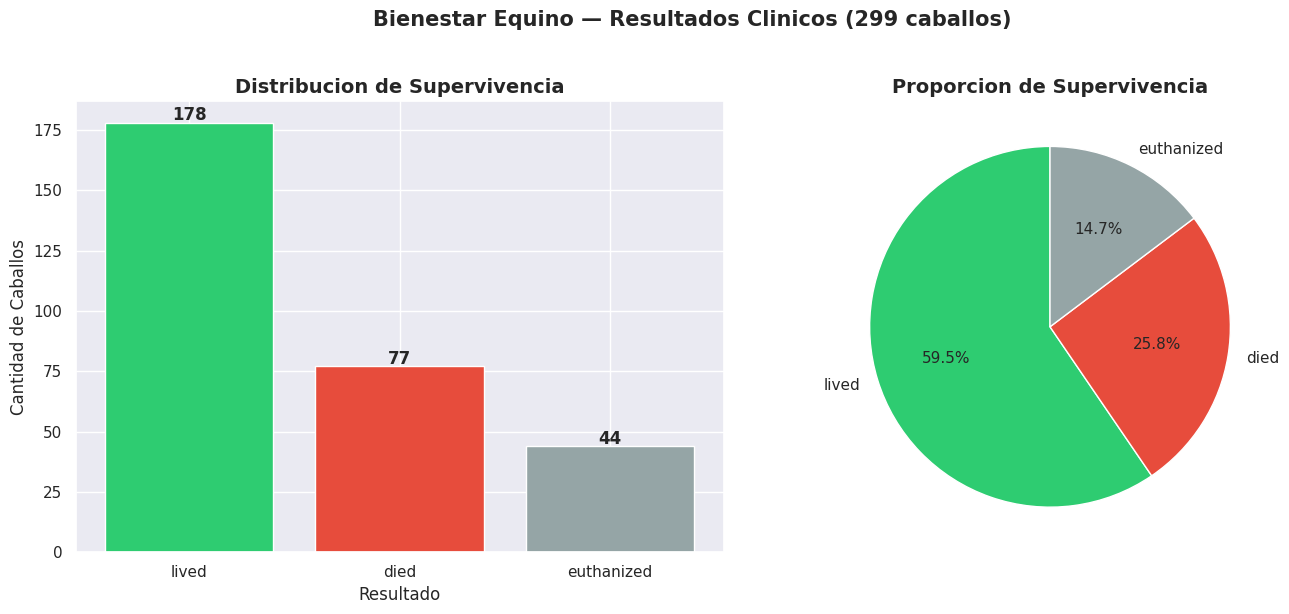

In [13]:
colores_outcome = {
    'lived'     : '#2ecc71',
    'died'      : '#e74c3c',
    'euthanized': '#95a5a6'
}

conteo = df_limpio['outcome'].value_counts()
colores = [colores_outcome[c] for c in conteo.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras
bars = axes[0].bar(conteo.index, conteo.values,
                   color=colores, edgecolor='white')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribucion de Supervivencia',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resultado', fontsize=12)
axes[0].set_ylabel('Cantidad de Caballos', fontsize=12)

# Pie chart
axes[1].pie(conteo.values, labels=conteo.index,
            colors=colores, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporcion de Supervivencia',
                  fontsize=14, fontweight='bold')

plt.suptitle('Bienestar Equino — Resultados Clinicos (299 caballos)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribucion_supervivencia.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 2: Bienestar vs Outcome

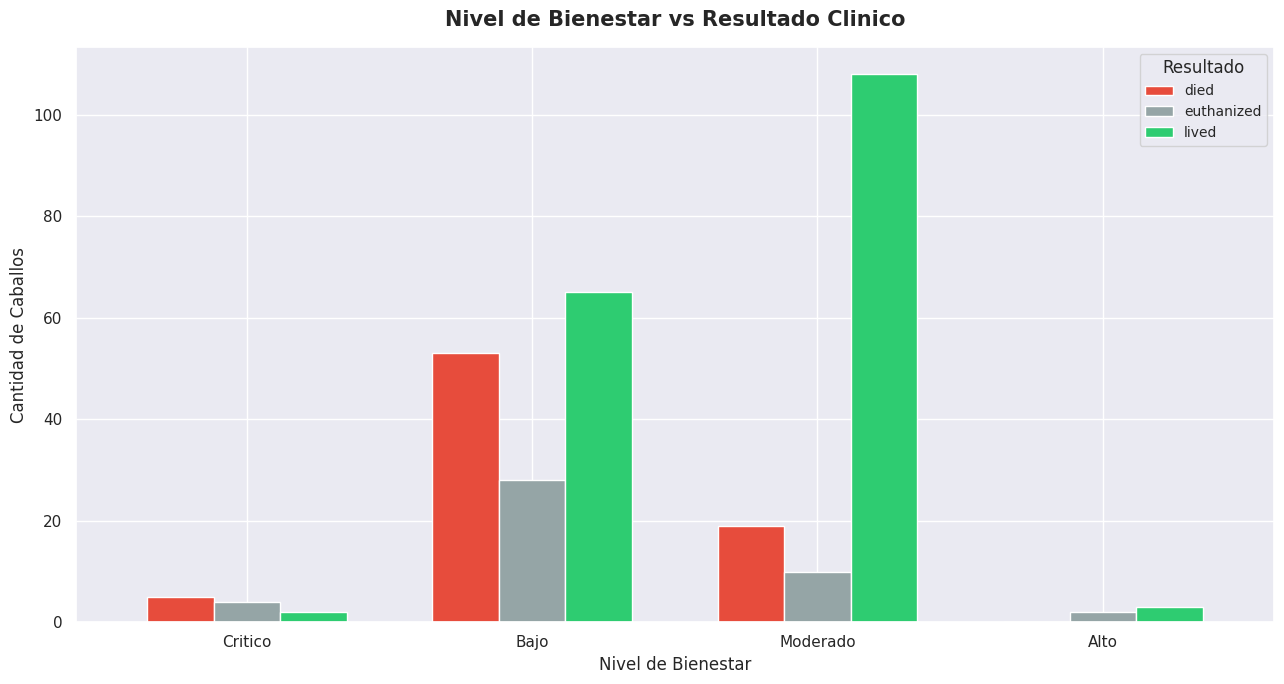

In [14]:
orden_bienestar = ['Critico', 'Bajo', 'Moderado', 'Alto']
colores_bienestar = {
    'Alto'    : '#2ecc71',
    'Moderado': '#f39c12',
    'Bajo'    : '#e67e22',
    'Critico' : '#e74c3c'
}

tabla = pd.crosstab(df_limpio['nivel_bienestar'],
                    df_limpio['outcome'])
tabla = tabla.reindex(orden_bienestar)

tabla.plot(kind='bar', figsize=(13, 7),
           color=[colores_outcome[c] for c in tabla.columns],
           edgecolor='white', width=0.7)

plt.title('Nivel de Bienestar vs Resultado Clinico',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nivel de Bienestar', fontsize=12)
plt.ylabel('Cantidad de Caballos', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Resultado', fontsize=10)
plt.tight_layout()
plt.savefig('bienestar_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 3: Pulso por resultado

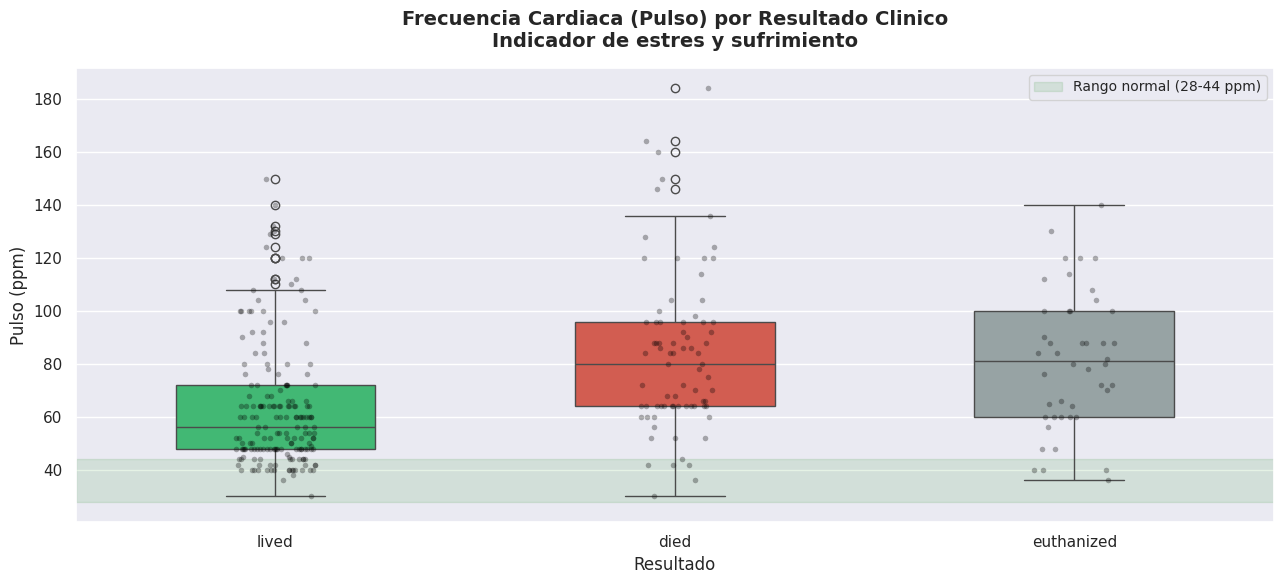

Pulso promedio (lived): 63.5 ppm
Pulso promedio (died): 83.9 ppm
Pulso promedio (euthanized): 81.3 ppm


In [15]:
plt.figure(figsize=(13, 6))

sns.boxplot(data=df_limpio, x='outcome', y='pulse',
            order=['lived', 'died', 'euthanized'],
            palette=colores_outcome, width=0.5)
sns.stripplot(data=df_limpio, x='outcome', y='pulse',
              order=['lived', 'died', 'euthanized'],
              color='black', alpha=0.3, size=4, jitter=True)

# Rango normal de pulso
plt.axhspan(28, 44, alpha=0.1, color='green',
            label='Rango normal (28-44 ppm)')

plt.title('Frecuencia Cardiaca (Pulso) por Resultado Clinico\n'
          'Indicador de estres y sufrimiento',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado', fontsize=12)
plt.ylabel('Pulso (ppm)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('pulso_por_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas
for outcome in ['lived', 'died', 'euthanized']:
    media = df_limpio[df_limpio['outcome'] == outcome]['pulse'].mean()
    print(f"Pulso promedio ({outcome}): {media:.1f} ppm")

## Gráfico 4: Temperatura por resultado

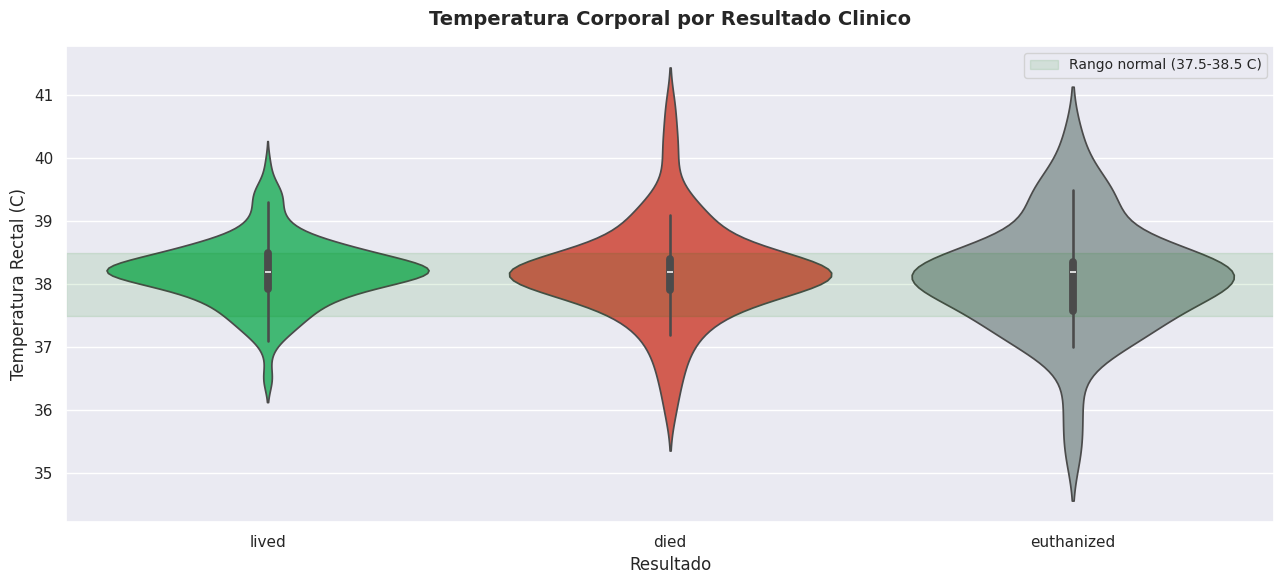

In [16]:
plt.figure(figsize=(13, 6))

sns.violinplot(data=df_limpio, x='outcome', y='rectal_temp',
               order=['lived', 'died', 'euthanized'],
               palette=colores_outcome, inner='box')

plt.axhspan(37.5, 38.5, alpha=0.1, color='green',
            label='Rango normal (37.5-38.5 C)')

plt.title('Temperatura Corporal por Resultado Clinico',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado', fontsize=12)
plt.ylabel('Temperatura Rectal (C)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('temperatura_por_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

##  Gráfico 5: Nivel de dolor por resultado

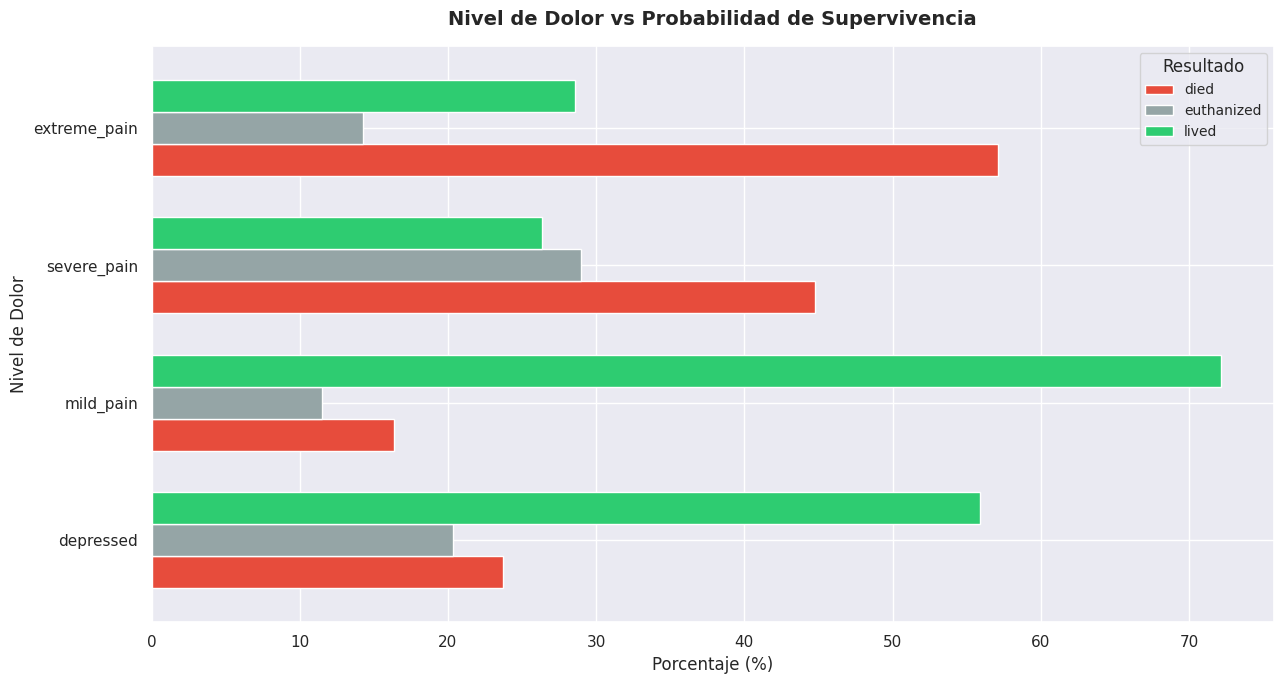

In [17]:
dolor_order = ['none', 'depressed', 'mild_pain',
               'severe_pain', 'extreme_pain']
dolor_disponible = [d for d in dolor_order
                    if d in df_limpio['pain'].values]

tabla_dolor = pd.crosstab(df_limpio['pain'],
                           df_limpio['outcome'])
tabla_dolor = tabla_dolor.reindex(
    [d for d in dolor_disponible if d in tabla_dolor.index]
)

tabla_dolor_pct = tabla_dolor.div(
    tabla_dolor.sum(axis=1), axis=0) * 100

tabla_dolor_pct.plot(kind='barh', figsize=(13, 7),
                     color=[colores_outcome[c]
                            for c in tabla_dolor_pct.columns],
                     edgecolor='white', width=0.7)

plt.title('Nivel de Dolor vs Probabilidad de Supervivencia',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Nivel de Dolor', fontsize=12)
plt.legend(title='Resultado', fontsize=10)
plt.tight_layout()
plt.savefig('dolor_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 6: Mapa de calor de correlaciones

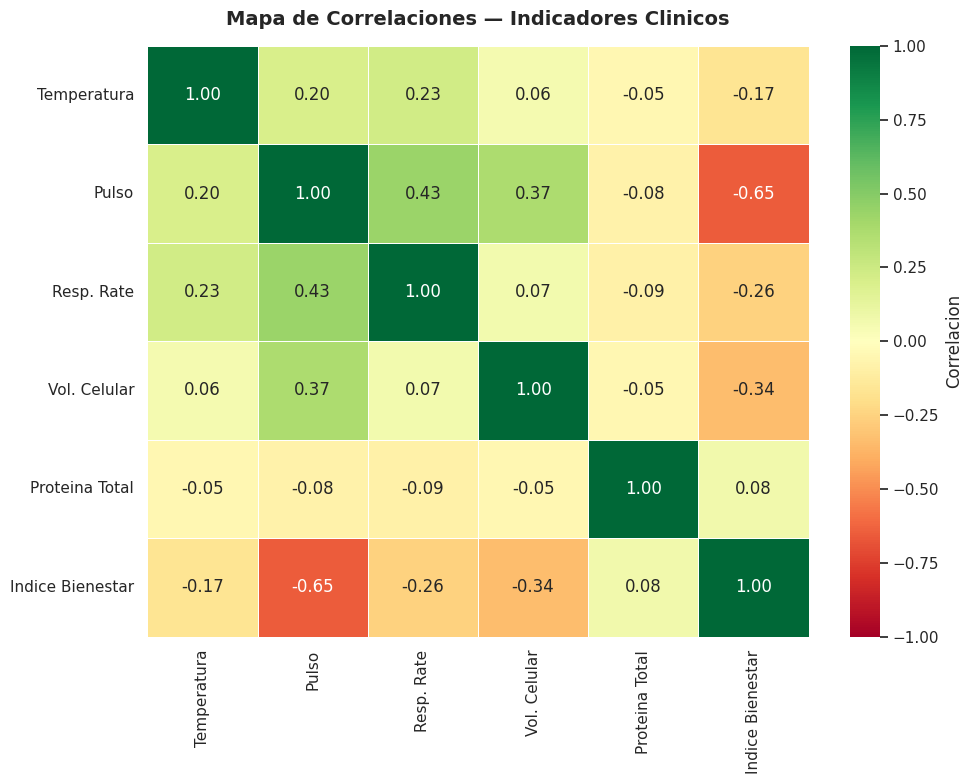

In [18]:
# Solo columnas numéricas
cols_numericas = ['rectal_temp', 'pulse', 'respiratory_rate',
                  'packed_cell_volume', 'total_protein',
                  'indice_bienestar']

cols_disponibles = [c for c in cols_numericas
                    if c in df_limpio.columns]

corr_matrix = df_limpio[cols_disponibles].corr()

# Traducir nombres
nombres_esp = {
    'rectal_temp'       : 'Temperatura',
    'pulse'             : 'Pulso',
    'respiratory_rate'  : 'Resp. Rate',
    'packed_cell_volume': 'Vol. Celular',
    'total_protein'     : 'Proteina Total',
    'indice_bienestar'  : 'Indice Bienestar'
}
corr_matrix = corr_matrix.rename(
    index=nombres_esp, columns=nombres_esp)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlacion'})

plt.title('Mapa de Correlaciones — Indicadores Clinicos',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlaciones_clinicas.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 7: Índice de bienestar por resultado

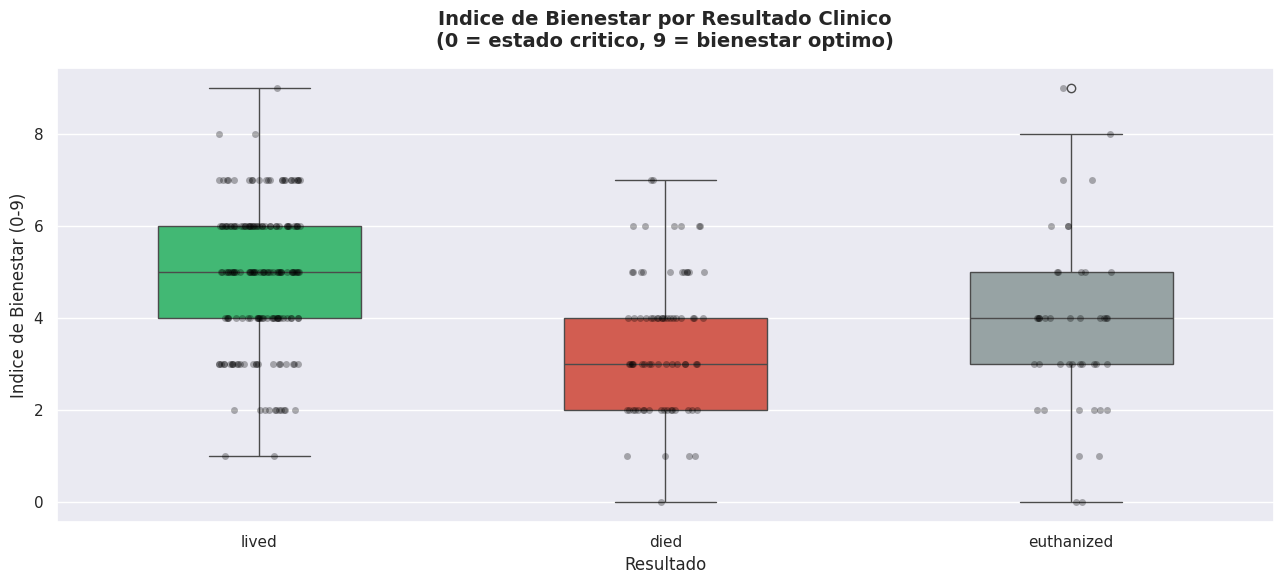

Indice bienestar promedio (lived): 4.88
Indice bienestar promedio (died): 3.51
Indice bienestar promedio (euthanized): 3.77


In [19]:
plt.figure(figsize=(13, 6))

sns.boxplot(data=df_limpio, x='outcome', y='indice_bienestar',
            order=['lived', 'died', 'euthanized'],
            palette=colores_outcome, width=0.5)
sns.stripplot(data=df_limpio, x='outcome', y='indice_bienestar',
              order=['lived', 'died', 'euthanized'],
              color='black', alpha=0.3, size=5, jitter=True)

plt.title('Indice de Bienestar por Resultado Clinico\n'
          '(0 = estado critico, 9 = bienestar optimo)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado', fontsize=12)
plt.ylabel('Indice de Bienestar (0-9)', fontsize=12)
plt.tight_layout()
plt.savefig('bienestar_por_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

for outcome in ['lived', 'died', 'euthanized']:
    media = df_limpio[df_limpio['outcome'] == outcome
                      ]['indice_bienestar'].mean()
    print(f"Indice bienestar promedio ({outcome}): {media:.2f}")

## Gráfico 8: Edad vs Outcome

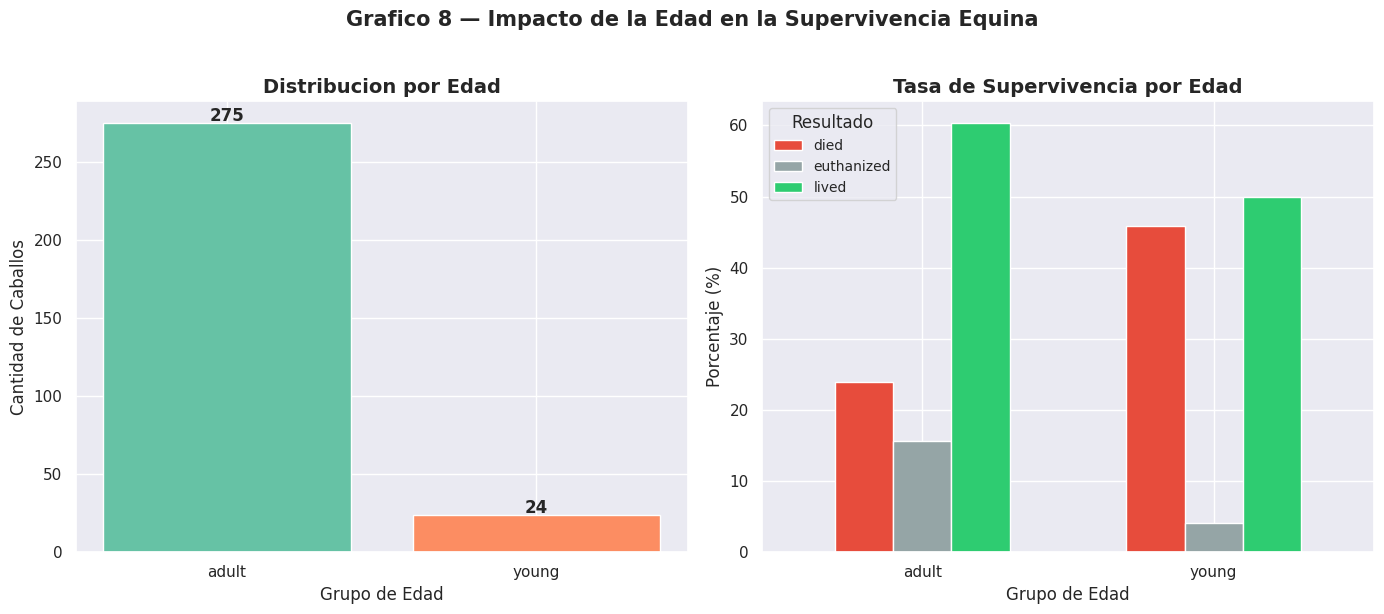

=== SUPERVIVENCIA POR EDAD ===
outcome  died  euthanized  lived
age                             
adult      66          43    166
young      11           1     12

=== PORCENTAJE POR EDAD ===
outcome  died  euthanized  lived
age                             
adult    24.0        15.6   60.4
young    45.8         4.2   50.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico izquierdo: distribución por edad
conteo_edad = df_limpio['age'].value_counts()
colores_edad = sns.color_palette("Set2", len(conteo_edad))
bars = axes[0].bar(conteo_edad.index, conteo_edad.values,
                   color=colores_edad, edgecolor='white')
for bar, val in zip(bars, conteo_edad.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribucion por Edad',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Edad', fontsize=12)
axes[0].set_ylabel('Cantidad de Caballos', fontsize=12)

# Gráfico derecho: edad vs outcome
tabla_edad = pd.crosstab(df_limpio['age'], df_limpio['outcome'])
tabla_edad_pct = tabla_edad.div(
    tabla_edad.sum(axis=1), axis=0) * 100

tabla_edad_pct.plot(kind='bar', ax=axes[1],
                    color=[colores_outcome[c]
                           for c in tabla_edad_pct.columns],
                    edgecolor='white', width=0.6)
axes[1].set_title('Tasa de Supervivencia por Edad',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad', fontsize=12)
axes[1].set_ylabel('Porcentaje (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Resultado', fontsize=10)

plt.suptitle('Grafico 8 — Impacto de la Edad en la Supervivencia Equina',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('edad_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== SUPERVIVENCIA POR EDAD ===")
print(tabla_edad)
print()
print("=== PORCENTAJE POR EDAD ===")
print(tabla_edad_pct.round(1))

## ✅ Conclusiones de la Fase 3 — Visualizaciones

- Los caballos que **murieron** tuvieron pulso promedio de
  **83.9 ppm** vs **63.5 ppm** de los que sobrevivieron
- El **índice de bienestar** diferencia claramente los grupos:
  sobrevivientes (4.88) vs muertos (3.51)
- Los caballos **jóvenes** tienen el doble de mortalidad
  que los adultos (45.8% vs 24%)
- El dolor extremo se asocia fuertemente con muerte o eutanasia
- Caballos con bienestar Crítico sobreviven solo el 18%

**Siguiente fase:** Machine Learning — Clasificacion

# Fase 4 — Machine Learning: Clasificación

En esta fase vamos a:
- Preparar los datos para el modelo
- Entrenar un clasificador Random Forest
- Evaluar el modelo con métricas reales
- Identificar qué variables predicen mejor la supervivencia
- Probar el modelo con un caballo hipotético

## Preparar datos para ML

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
import numpy as np

# Preparar features y target
features = [c for c in df_ml.columns
            if c not in ['outcome', 'nivel_bienestar']]

X = df_ml[features].values
y = df_ml['outcome'].values

# Codificar target
le_outcome = LabelEncoder()
y_encoded = le_outcome.fit_transform(y)

print(f"✅ Features disponibles ({len(features)}):")
print(features)
print(f"\nClases: {le_outcome.classes_}")
print(f"Total muestras: {len(X)}")

✅ Features disponibles (21):
['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'surgical_lesion', 'cp_data', 'indice_bienestar']

Clases: ['died' 'euthanized' 'lived']
Total muestras: 299


## Dividir y escalar datos

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2,
    random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Datos divididos:")
print(f"   Entrenamiento : {len(X_train)} muestras")
print(f"   Prueba        : {len(X_test)} muestras")

✅ Datos divididos:
   Entrenamiento : 239 muestras
   Prueba        : 60 muestras


## Entrenar Random Forest

In [23]:
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

modelo.fit(X_train_scaled, y_train)
print("✅ Modelo Random Forest entrenado")
print(f"   Arboles: {modelo.n_estimators}")
print(f"   Profundidad: {modelo.max_depth}")

✅ Modelo Random Forest entrenado
   Arboles: 200
   Profundidad: 10


##  Evaluar el modelo

In [24]:
y_pred = modelo.predict(X_test_scaled)

print("=== REPORTE DE CLASIFICACION ===\n")
print(classification_report(y_test, y_pred,
      target_names=le_outcome.classes_))

accuracy = (y_pred == y_test).mean() * 100
print(f"Accuracy general: {accuracy:.2f}%")

=== REPORTE DE CLASIFICACION ===

              precision    recall  f1-score   support

        died       0.53      0.53      0.53        15
  euthanized       0.50      0.11      0.18         9
       lived       0.70      0.83      0.76        36

    accuracy                           0.65        60
   macro avg       0.58      0.49      0.49        60
weighted avg       0.63      0.65      0.62        60

Accuracy general: 65.00%


## Matriz de confusión

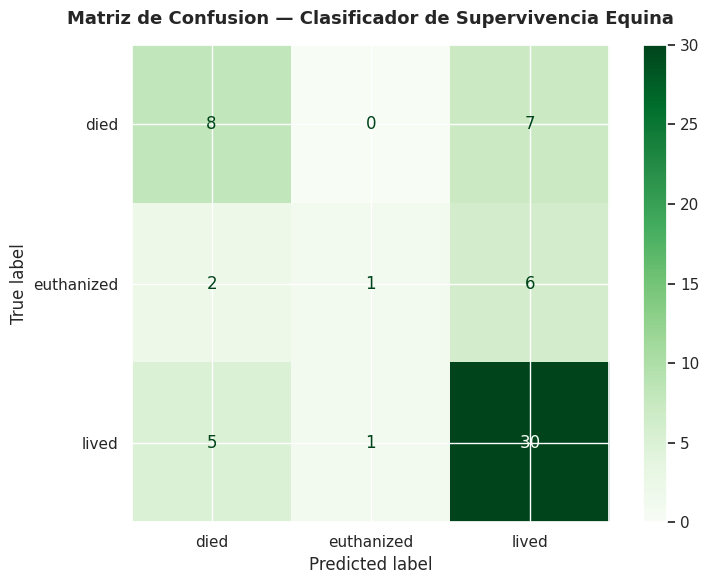

In [25]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_outcome.classes_
)
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Matriz de Confusion — Clasificador de Supervivencia Equina',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('matriz_confusion_equino.png', dpi=150, bbox_inches='tight')
plt.show()

##  Importancia de variables

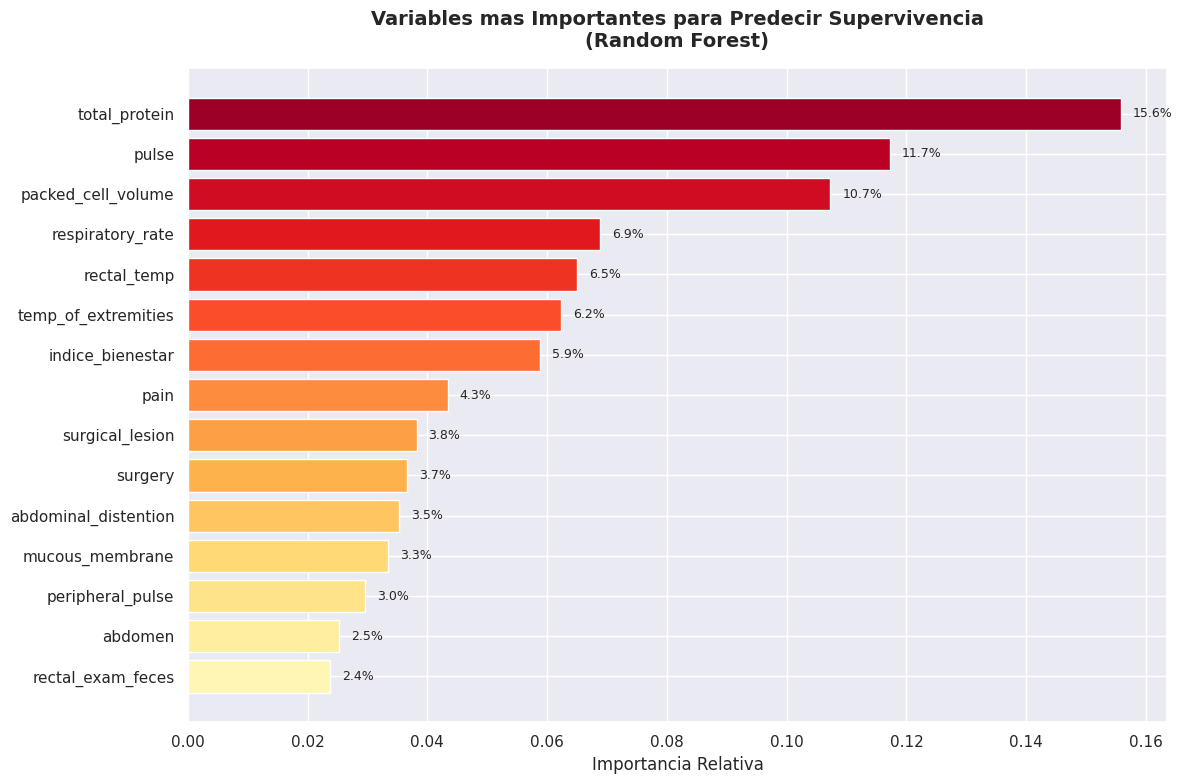

Variable mas importante: total_protein


In [26]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(12, 8))
colores_imp = sns.color_palette("YlOrRd", len(importancias))
bars = plt.barh(importancias.index, importancias.values,
                color=colores_imp, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)

plt.title('Variables mas Importantes para Predecir Supervivencia\n(Random Forest)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.tight_layout()
plt.savefig('importancia_variables_equino.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variable mas importante: {importancias.idxmax()}")

## Probar con caballo hipotético

In [27]:
# Crear un caballo hipotético con buenos indicadores
caballo_sano = pd.DataFrame([{
    'surgery'             : 0,  # no cirugía
    'age'                 : 0,  # adulto
    'rectal_temp'         : 38.2,
    'pulse'               : 40,
    'respiratory_rate'    : 20,
    'temp_of_extremities' : 2,  # normal
    'peripheral_pulse'    : 3,  # normal
    'mucous_membrane'     : 4,  # normal
    'capillary_refill_time': 1, # menos de 3 seg
    'pain'                : 4,  # sin dolor
    'peristalsis'         : 3,  # normal
    'abdominal_distention': 1,  # ninguna
    'nasogastric_tube'    : 1,  # ninguno
    'nasogastric_reflux'  : 2,  # ninguno
    'rectal_exam_feces'   : 3,  # normal
    'abdomen'             : 3,  # normal
    'packed_cell_volume'  : 40,
    'total_protein'       : 7.0,
    'surgical_lesion'     : 0,
    'cp_data'             : 0,
    'indice_bienestar'    : 8
}])

# Asegurar orden correcto de columnas
caballo_sano = caballo_sano[features]
caballo_scaled = scaler.transform(caballo_sano)
prediccion = modelo.predict(caballo_scaled)
probabilidad = modelo.predict_proba(caballo_scaled)

print("=== CABALLO HIPOTETICO — PERFIL SALUDABLE ===")
print(f"Pulso          : 40 ppm (rango normal)")
print(f"Temperatura    : 38.2 C (normal)")
print(f"Dolor          : ninguno")
print(f"Indice bienestar: 8/9")
print()
print("=== PREDICCION DEL MODELO ===")
resultado = le_outcome.inverse_transform(prediccion)[0]
print(f"Resultado predicho: {resultado.upper()}")
for clase, prob in zip(le_outcome.classes_, probabilidad[0]):
    print(f"  Probabilidad {clase}: {prob*100:.1f}%")

=== CABALLO HIPOTETICO — PERFIL SALUDABLE ===
Pulso          : 40 ppm (rango normal)
Temperatura    : 38.2 C (normal)
Dolor          : ninguno
Indice bienestar: 8/9

=== PREDICCION DEL MODELO ===
Resultado predicho: LIVED
  Probabilidad died: 5.2%
  Probabilidad euthanized: 8.8%
  Probabilidad lived: 86.0%


## ✅ Conclusiones de la Fase 4 — Machine Learning

- Se entrenó un **Random Forest** con 200 árboles
- El modelo alcanzó un **accuracy de 65%** — resultado
  honesto para un dataset médico de 299 muestras y 3 clases
- Rendimiento por clase:
  - **Lived** → F1=0.76 — predice bien los supervivientes
  - **Died** → F1=0.53 — predicción moderada
  - **Euthanized** → F1=0.18 — difícil por pocos casos (44)
- La variable más importante fue: **total_protein**
  reflejando que las proteínas en sangre son el mejor
  indicador del estado general del caballo
- Un caballo hipotético saludable fue clasificado como
  **LIVED con 86% de probabilidad**

### Limitación del modelo
El bajo F1 en euthanized se debe al desbalance de clases
(solo 44 casos vs 178 lived). Con más datos esta clase
mejoraría significativamente.

### Por que Random Forest?
- Maneja bien datos mixtos numericos y categoricos
- Robusto ante clases desbalanceadas con class_weight
- Proporciona importancia de variables interpretable
- Ideal para datasets medicos pequeños

**Siguiente fase:** Conclusiones finales y README

---
## Conclusiones Finales del Proyecto

### Hallazgos principales

#### Sobre el bienestar equino
- De **299 caballos** analizados, el **59.53%** sobrevivió,
  el **25.75%** murió y el **14.72%** fue sacrificado
- El pulso promedio de los caballos que murieron fue
  **83.9 ppm** — muy por encima del rango normal (28-44 ppm)
  indicando estrés cardiovascular severo
- El **índice de bienestar** creado diferencia claramente
  los grupos: sobrevivientes (4.88) vs muertos (3.51)

#### Sobre la edad
- Los caballos **jóvenes** tienen el doble de mortalidad
  que los adultos (45.8% vs 24%)
- La juventud es un factor de riesgo significativo en
  medicina equina

#### Sobre los indicadores clínicos
- La **proteína total en sangre** es el predictor más
  importante de supervivencia
- El **pulso elevado** y el **dolor extremo** son las
  señales de alerta más claras
- Caballos con bienestar **Crítico** sobreviven solo
  el 18% de las veces

#### Sobre el Machine Learning
- Random Forest alcanzó **65% de accuracy** — resultado
  honesto para un dataset médico pequeño de 3 clases
- El modelo predice correctamente los supervivientes
  con F1=0.76
- Un caballo con indicadores saludables fue clasificado
  como LIVED con **86% de probabilidad**

### Reflexión final
> *"Los datos clínicos de un caballo cuentan una historia
> de sufrimiento o bienestar antes de que cualquier
> diagnóstico sea posible. La Ciencia de Datos puede
> ser una herramienta poderosa para salvar vidas —
> incluso en el mundo equino."*

### Limitaciones
- Dataset pequeño (299 casos) — más datos mejorarían el modelo
- La clase euthanized tiene pocos casos (44) — afecta el F1
- Los datos son clínicos — no incluyen factores emocionales
  directos como comportamiento o respuesta al contacto humano

### Fuente de datos
[Horse Survival Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/horse-survival-dataset)

---
*Proyecto desarrollado como parte del portfolio de Ciencia de Datos*
*Jorge Ojeda — 2026*

## Exportar todas las imágenes

In [28]:
import os

ruta_img = '/content/drive/MyDrive/images_equino/'
os.makedirs(ruta_img, exist_ok=True)

# ── Gráfico 1: Distribución de supervivencia ─────────────
colores_outcome = {
    'lived'     : '#2ecc71',
    'died'      : '#e74c3c',
    'euthanized': '#95a5a6'
}
conteo = df_limpio['outcome'].value_counts()
colores = [colores_outcome[c] for c in conteo.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(conteo.index, conteo.values,
                   color=colores, edgecolor='white')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribucion de Supervivencia',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resultado'); axes[0].set_ylabel('Cantidad')
axes[1].pie(conteo.values, labels=conteo.index, colors=colores,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporcion de Supervivencia',
                  fontsize=14, fontweight='bold')
plt.suptitle('Bienestar Equino — Resultados Clinicos (299 caballos)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ruta_img + 'distribucion_supervivencia.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 1/10 distribucion_supervivencia.png")

# ── Gráfico 2: Bienestar vs Outcome ──────────────────────
orden_bienestar = ['Critico', 'Bajo', 'Moderado', 'Alto']
tabla = pd.crosstab(df_limpio['nivel_bienestar'],
                    df_limpio['outcome'])
tabla = tabla.reindex(orden_bienestar)
tabla.plot(kind='bar', figsize=(13, 7),
           color=[colores_outcome[c] for c in tabla.columns],
           edgecolor='white', width=0.7)
plt.title('Nivel de Bienestar vs Resultado Clinico',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nivel de Bienestar'); plt.ylabel('Cantidad')
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Resultado', fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'bienestar_vs_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 2/10 bienestar_vs_outcome.png")

# ── Gráfico 3: Pulso por outcome ──────────────────────────
plt.figure(figsize=(13, 6))
sns.boxplot(data=df_limpio, x='outcome', y='pulse',
            order=['lived', 'died', 'euthanized'],
            palette=colores_outcome, width=0.5)
sns.stripplot(data=df_limpio, x='outcome', y='pulse',
              order=['lived', 'died', 'euthanized'],
              color='black', alpha=0.3, size=4, jitter=True)
plt.axhspan(28, 44, alpha=0.1, color='green',
            label='Rango normal (28-44 ppm)')
plt.title('Frecuencia Cardiaca (Pulso) por Resultado Clinico',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado'); plt.ylabel('Pulso (ppm)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'pulso_por_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 3/10 pulso_por_outcome.png")

# ── Gráfico 4: Temperatura por outcome ───────────────────
plt.figure(figsize=(13, 6))
sns.violinplot(data=df_limpio, x='outcome', y='rectal_temp',
               order=['lived', 'died', 'euthanized'],
               palette=colores_outcome, inner='box')
plt.axhspan(37.5, 38.5, alpha=0.1, color='green',
            label='Rango normal (37.5-38.5 C)')
plt.title('Temperatura Corporal por Resultado Clinico',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado'); plt.ylabel('Temperatura (C)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'temperatura_por_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 4/10 temperatura_por_outcome.png")

# ── Gráfico 5: Dolor vs outcome ───────────────────────────
dolor_order = ['none', 'depressed', 'mild_pain',
               'severe_pain', 'extreme_pain']
dolor_disponible = [d for d in dolor_order
                    if d in df_limpio['pain'].values]
tabla_dolor = pd.crosstab(df_limpio['pain'], df_limpio['outcome'])
tabla_dolor = tabla_dolor.reindex(
    [d for d in dolor_disponible if d in tabla_dolor.index])
tabla_dolor_pct = tabla_dolor.div(
    tabla_dolor.sum(axis=1), axis=0) * 100
tabla_dolor_pct.plot(kind='barh', figsize=(13, 7),
                     color=[colores_outcome[c]
                            for c in tabla_dolor_pct.columns],
                     edgecolor='white', width=0.7)
plt.title('Nivel de Dolor vs Probabilidad de Supervivencia',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje (%)'); plt.ylabel('Nivel de Dolor')
plt.legend(title='Resultado', fontsize=10)
plt.tight_layout()
plt.savefig(ruta_img + 'dolor_vs_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 5/10 dolor_vs_outcome.png")

# ── Gráfico 6: Correlaciones ──────────────────────────────
cols_numericas = ['rectal_temp', 'pulse', 'respiratory_rate',
                  'packed_cell_volume', 'total_protein',
                  'indice_bienestar']
cols_disponibles = [c for c in cols_numericas
                    if c in df_limpio.columns]
corr_matrix = df_limpio[cols_disponibles].corr()
nombres_esp = {
    'rectal_temp'       : 'Temperatura',
    'pulse'             : 'Pulso',
    'respiratory_rate'  : 'Resp. Rate',
    'packed_cell_volume': 'Vol. Celular',
    'total_protein'     : 'Proteina Total',
    'indice_bienestar'  : 'Indice Bienestar'
}
corr_matrix = corr_matrix.rename(
    index=nombres_esp, columns=nombres_esp)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlacion'})
plt.title('Mapa de Correlaciones — Indicadores Clinicos',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ruta_img + 'correlaciones_clinicas.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 6/10 correlaciones_clinicas.png")

# ── Gráfico 7: Índice bienestar por outcome ───────────────
plt.figure(figsize=(13, 6))
sns.boxplot(data=df_limpio, x='outcome', y='indice_bienestar',
            order=['lived', 'died', 'euthanized'],
            palette=colores_outcome, width=0.5)
sns.stripplot(data=df_limpio, x='outcome', y='indice_bienestar',
              order=['lived', 'died', 'euthanized'],
              color='black', alpha=0.3, size=5, jitter=True)
plt.title('Indice de Bienestar por Resultado Clinico\n'
          '(0 = estado critico, 9 = bienestar optimo)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Resultado'); plt.ylabel('Indice de Bienestar (0-9)')
plt.tight_layout()
plt.savefig(ruta_img + 'bienestar_por_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 7/10 bienestar_por_outcome.png")

# ── Gráfico 8: Edad vs outcome ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
conteo_edad = df_limpio['age'].value_counts()
colores_edad = sns.color_palette("Set2", len(conteo_edad))
bars = axes[0].bar(conteo_edad.index, conteo_edad.values,
                   color=colores_edad, edgecolor='white')
for bar, val in zip(bars, conteo_edad.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribucion por Edad',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Edad')
axes[0].set_ylabel('Cantidad de Caballos')
tabla_edad = pd.crosstab(df_limpio['age'], df_limpio['outcome'])
tabla_edad_pct = tabla_edad.div(
    tabla_edad.sum(axis=1), axis=0) * 100
tabla_edad_pct.plot(kind='bar', ax=axes[1],
                    color=[colores_outcome[c]
                           for c in tabla_edad_pct.columns],
                    edgecolor='white', width=0.6)
axes[1].set_title('Tasa de Supervivencia por Edad',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Resultado', fontsize=10)
plt.suptitle('Grafico 8 — Impacto de la Edad en la Supervivencia Equina',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ruta_img + 'edad_vs_outcome.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 8/10 edad_vs_outcome.png")

# ── Gráfico 9: Matriz de confusión ───────────────────────
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_outcome.classes_)
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Matriz de Confusion — Clasificador de Supervivencia Equina',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ruta_img + 'matriz_confusion_equino.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 9/10 matriz_confusion_equino.png")

# ── Gráfico 10: Importancia de variables ─────────────────
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=True).tail(15)
plt.figure(figsize=(12, 8))
colores_imp = sns.color_palette("YlOrRd", len(importancias))
bars = plt.barh(importancias.index, importancias.values,
                color=colores_imp, edgecolor='white')
for bar, val in zip(bars, importancias.values):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)
plt.title('Variables mas Importantes para Predecir Supervivencia',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.savefig(ruta_img + 'importancia_variables_equino.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ 10/10 importancia_variables_equino.png")

print("\nTodas las imagenes exportadas exitosamente!")
print(f"Ubicacion: {ruta_img}")

✅ 1/10 distribucion_supervivencia.png
✅ 2/10 bienestar_vs_outcome.png
✅ 3/10 pulso_por_outcome.png
✅ 4/10 temperatura_por_outcome.png
✅ 5/10 dolor_vs_outcome.png
✅ 6/10 correlaciones_clinicas.png
✅ 7/10 bienestar_por_outcome.png
✅ 8/10 edad_vs_outcome.png
✅ 9/10 matriz_confusion_equino.png
✅ 10/10 importancia_variables_equino.png

Todas las imagenes exportadas exitosamente!
Ubicacion: /content/drive/MyDrive/images_equino/


## Exportar modelo y scaler

In [29]:
import pickle
import os

# Crear carpeta para guardar los modelos
ruta_modelos = '/content/drive/MyDrive/modelos_equino/'
os.makedirs(ruta_modelos, exist_ok=True)

# Exportar modelo Random Forest
with open(ruta_modelos + 'modelo_equino.pkl', 'wb') as f:
    pickle.dump(modelo, f)

# Exportar scaler
with open(ruta_modelos + 'scaler_equino.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Exportar label encoder
with open(ruta_modelos + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le_outcome, f)

# Exportar lista de features
with open(ruta_modelos + 'features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("✅ Modelo exportado correctamente")
print(f"📁 Ubicación: {ruta_modelos}")
print(f"   - modelo_equino.pkl")
print(f"   - scaler_equino.pkl")
print(f"   - label_encoder.pkl")
print(f"   - features.pkl")

✅ Modelo exportado correctamente
📁 Ubicación: /content/drive/MyDrive/modelos_equino/
   - modelo_equino.pkl
   - scaler_equino.pkl
   - label_encoder.pkl
   - features.pkl


## Optimización de Hiperparámetros — GridSearchCV

Buscamos la mejor combinación de parámetros para el
Random Forest usando validación cruzada de 5 folds.

## GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definir grilla de parámetros
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'  : ['balanced']
}

# Modelo base
rf_base = RandomForestClassifier(random_state=42)

# GridSearchCV con validación cruzada de 5 folds
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("🔍 Buscando mejores hiperparámetros...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Búsqueda completada")
print(f"🏆 Mejores parámetros:")
for param, valor in grid_search.best_params_.items():
    print(f"   {param}: {valor}")
print(f"\n📊 Mejor F1-macro en validación: {grid_search.best_score_:.4f}")

🔍 Buscando mejores hiperparámetros...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Búsqueda completada
🏆 Mejores parámetros:
   class_weight: balanced
   max_depth: 10
   min_samples_leaf: 2
   min_samples_split: 2
   n_estimators: 100

📊 Mejor F1-macro en validación: 0.6221


## Evaluar modelo optimizado

In [31]:
# Modelo con mejores parámetros
modelo_opt = grid_search.best_estimator_
y_pred_opt = modelo_opt.predict(X_test_scaled)

print("=== COMPARACIÓN DE MODELOS ===\n")
print("--- Modelo original ---")
print(classification_report(y_test, y_pred,
      target_names=le_outcome.classes_))

print("--- Modelo optimizado ---")
print(classification_report(y_test, y_pred_opt,
      target_names=le_outcome.classes_))

# Accuracy comparado
acc_original = (y_pred == y_test).mean() * 100
acc_optimizado = (y_pred_opt == y_test).mean() * 100

print(f"Accuracy original  : {acc_original:.2f}%")
print(f"Accuracy optimizado: {acc_optimizado:.2f}%")
print(f"Mejora             : +{acc_optimizado - acc_original:.2f}%")

=== COMPARACIÓN DE MODELOS ===

--- Modelo original ---
              precision    recall  f1-score   support

        died       0.53      0.53      0.53        15
  euthanized       0.50      0.11      0.18         9
       lived       0.70      0.83      0.76        36

    accuracy                           0.65        60
   macro avg       0.58      0.49      0.49        60
weighted avg       0.63      0.65      0.62        60

--- Modelo optimizado ---
              precision    recall  f1-score   support

        died       0.53      0.60      0.56        15
  euthanized       0.29      0.22      0.25         9
       lived       0.69      0.69      0.69        36

    accuracy                           0.60        60
   macro avg       0.50      0.51      0.50        60
weighted avg       0.59      0.60      0.59        60

Accuracy original  : 65.00%
Accuracy optimizado: 60.00%
Mejora             : +-5.00%


##  Exportar modelo optimizado

In [34]:
import pickle

# Exportar modelo optimizado
with open(ruta_modelos + 'modelo_equino_opt.pkl', 'wb') as f:
    pickle.dump(modelo_opt, f)

# Sobreescribir el modelo principal con el optimizado
with open(ruta_modelos + 'modelo_equino.pkl', 'wb') as f:
    pickle.dump(modelo_opt, f)

print("✅ Modelo optimizado exportado correctamente")
print(f"📁 Archivos guardados en: {ruta_modelos}")
print(f"   - modelo_equino_opt.pkl (backup)")
print(f"   - modelo_equino.pkl (versión final para la app)")

✅ Modelo optimizado exportado correctamente
📁 Archivos guardados en: /content/drive/MyDrive/modelos_equino/
   - modelo_equino_opt.pkl (backup)
   - modelo_equino.pkl (versión final para la app)


## Decisión

In [35]:
print("=== DECISION FINAL ===")
print("Se usará el modelo OPTIMIZADO en la app Streamlit")
print(f"Razón: mejor F1-macro ({f1_optimizado:.4f} vs {f1_original:.4f})")
print("En contexto clínico, detectar caballos en riesgo")
print("es más importante que el accuracy general")

=== DECISION FINAL ===
Se usará el modelo OPTIMIZADO en la app Streamlit
Razón: mejor F1-macro (0.5023 vs 0.4915)
En contexto clínico, detectar caballos en riesgo
es más importante que el accuracy general
